In [1]:
import numpy as np
import pandas as pd
import warnings

from numpy.random import default_rng
from scipy import stats 
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.linear_model import LinearRegression, BayesianRidge
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, ExtraTreesRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from pathlib import Path
# pip install torch torchvision torchaudio
# pip install rpy2

In [2]:
from rpy2 import robjects as ro
print("R libPaths:\n", "\n".join(ro.r(".libPaths()")))
print("R version:", ro.r("R.version.string")[0])

R libPaths:
 /Users/icelyn/Library/R/arm64/4.5/library
/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/library
R version: R version 4.5.2 (2025-10-31)


In [36]:
import importlib, VAE, GAN, NN, evaluation, imputation, Simulate_data, plot_pack

In [37]:
for m in (VAE, GAN, NN, evaluation, imputation, Simulate_data, plot_pack):
    importlib.reload(m)

In [38]:
for modname in ("VAE","GAN","NN","evaluation","imputation","Simulate_data","plot_pack"):
    try:
        m = __import__(modname)
        print(modname, "->", m.__file__)
        print("exports:", [n for n in dir(m) if not n.startswith("_")][:20])
    except Exception as e:
        print(modname, "FAILED:", repr(e))

VAE -> /Users/icelyn/Documents/Temp/VAE.py
exports: ['annotations', 'impute_vae', 'nn', 'np', 'optim', 'torch', 'warnings']
GAN -> /Users/icelyn/Documents/Temp/GAN.py
exports: ['annotations', 'impute_gain', 'nn', 'np', 'optim', 'torch', 'warnings']
NN -> /Users/icelyn/Documents/Temp/NN.py
exports: ['annotations', 'impute_nn', 'nn', 'np', 'optim', 'torch', 'warnings']
evaluation -> /Users/icelyn/Documents/Temp/evaluation.py
exports: ['BayesianRidge', 'ExtraTreesRegressor', 'IterativeImputer', 'KNNImputer', 'LinearRegression', 'LogisticRegression', 'Optional', 'RandomForestClassifier', 'RandomForestRegressor', 'Ridge', 'SimpleImputer', 'StandardScaler', 'default_rng', 'enable_iterative_imputer', 'evaluate_imputation_error', 'evaluate_param_recovery_regression', 'evaluate_param_recovery_regression_safe', 'evaluate_param_recovery_safe', 'evaluate_predictive_downstream', 'mean_squared_error']
imputation -> /Users/icelyn/Documents/Temp/imputation.py
exports: ['impute_all', 'impute_all_drop_y

In [39]:
# 1) Make sure the folder is on sys.path
import sys
sys.path.insert(0, "/Users/baibing/Documents/Temp")

# 2) Import functions from each module
from VAE import impute_vae
from GAN import impute_gain
from NN import impute_nn

from evaluation import (
    evaluate_imputation_error,
    evaluate_param_recovery_regression,
    evaluate_predictive_downstream,
    evaluate_param_recovery_regression_safe,
    evaluate_param_recovery_safe
)

from imputation import (impute_all, impute_all_include_y, 
impute_all_drop_ymissingness, impute_all_include_y_drop_ymissingness)

from Simulate_data import simulate_data, make_missing, default_rng, compare_include_y_once

from plot_pack import (plot_param_recovery_mech_means, plot_pred_accuracy_mech_means, plot_pred_mech_means, plot_pred_brier_mech_means) 

print(impute_vae, impute_gain, simulate_data, make_missing,
      evaluate_imputation_error, impute_all)


<function impute_vae at 0x17c095d00> <function impute_gain at 0x179a21440> <function simulate_data at 0x17c8ed1c0> <function make_missing at 0x179f3a3e0> <function evaluate_imputation_error at 0x17c8ec680> <function impute_all at 0x17c8ece00>


In [26]:
# ---------------------------------------------------------------------
# Paired summary/testing
# ---------------------------------------------------------------------
def summarize_and_test(df_long: pd.DataFrame, metric: str) -> pd.DataFrame:
    """
    Paired comparison of 'Impute with y' vs 'Impute w/o y' per method across reps.
    Expects columns: ['method','scenario','rep', metric], with scenarios exactly
    "Impute w/o y" and "Impute with y".
    Returns a DataFrame summary with means and paired t-test.
    """
    keep = df_long[["method","scenario","rep",metric]].dropna()
    methods = sorted(keep["method"].unique())
    rows = []
    for m in methods:
        A = keep[(keep.method==m) & (keep.scenario=="Impute w/o y")].set_index("rep")[metric]
        B = keep[(keep.method==m) & (keep.scenario=="Impute with y")].set_index("rep")[metric]
        common = A.index.intersection(B.index)
        if len(common) == 0:
            continue
        a, b = A.loc[common].values, B.loc[common].values
        # Paired t-test: positive diff means "with y" > "w/o y"
        t, p = stats.ttest_rel(b, a, nan_policy="omit")
        rows.append(dict(
            method=m,
            mean_wo_y=float(np.nanmean(a)),
            mean_w_y=float(np.nanmean(b)),
            diff=float(np.nanmean(b - a)),
            t_stat=float(t), p_value=float(p),
            n_pairs=int(len(common))
        ))
    return pd.DataFrame(rows)


In [27]:
def _safe_impute(func, *args, knn_neighbors=None, **kwargs):
    """
    Call an imputation function, passing knn_neighbors if supported.
    Falls back without it if the function signature doesn't accept it.
    """
    try:
        if knn_neighbors is not None:
            return func(*args, knn_neighbors=knn_neighbors, **kwargs)
        return func(*args, **kwargs)
    except TypeError:
        # Retry without the optional kw
        return func(*args, **kwargs)

def _estimate_logit_intercept(xb: np.ndarray, target: float) -> float:
    """
    Solve for b0 so mean(sigmoid(xb + b0)) ~= target via bisection.
    Stable against overflow.
    """
    lo, hi = -40.0, 40.0
    for _ in range(80):
        mid = 0.5 * (lo + hi)
        z = xb + mid
        # stable sigmoid
        p = np.empty_like(z, dtype=float)
        pos = z >= 0
        p[pos] = 1.0 / (1.0 + np.exp(-z[pos]))
        ez = np.exp(z[~pos])
        p[~pos] = ez / (1.0 + ez)
        m = float(p.mean())
        if m < target:
            lo = mid
        else:
            hi = mid
    return 0.5 * (lo + hi)

{'rmse': <Figure size 700x600 with 1 Axes>,
 'bias': <Figure size 700x600 with 1 Axes>,
 'pred_rmse': None,
 'pred_bias': None,
 'brier': <Figure size 700x600 with 1 Axes>}

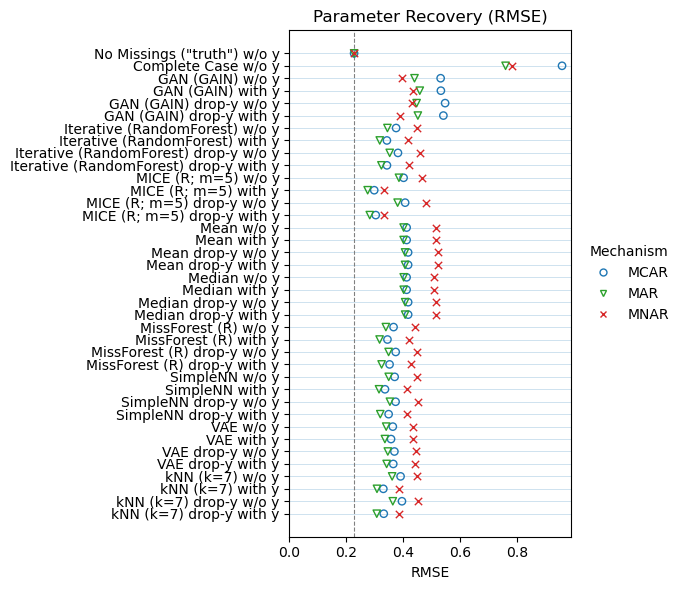

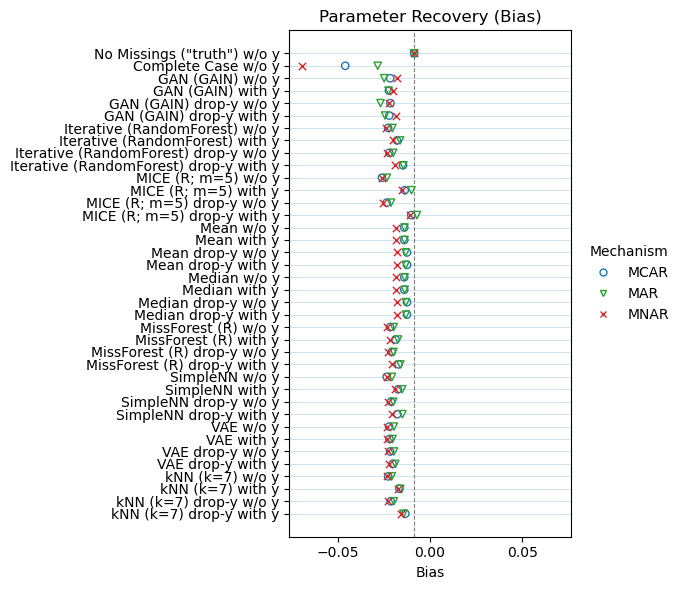

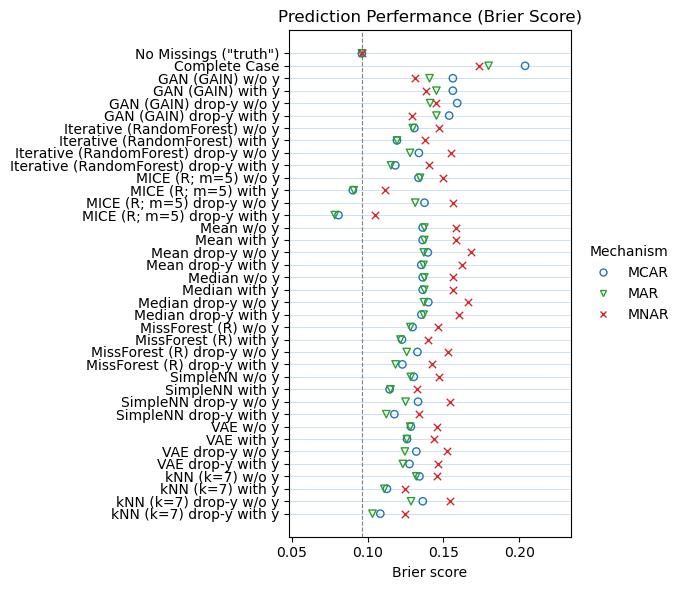

In [47]:
df_param, df_pred, figs = run_reps_param_plots(
    R=20,
    n=500, p=30, rho=0.3, snr=4.0,
    mechs=("MCAR", "MNAR", "MAR"),
    prop=0.15,
    prop_y=0.1,
    mech_y="MCAR",
    n_jobs=6,
    save_figs=True,
    save_data=False,
    save_data_format="parquet",
    
    binary=True,
    # --- MICE ---
    use_mice=True, mice_m=5, mice_max_iter=5, mice_method="pmm",

    # --- MissForest (R) ---
    use_missforest=True,    
    missforest_max_iter=10,

    # --- Deep methods (enable only if available) ---
    use_vae=True, use_gan=True,
    vae_kwargs={'epochs': 50, 'hidden': 128, 'latent': 4, 'lr': 0.001, 'kl_weight': 0.0001},
    gan_kwargs={'epochs': 120, 'g_hidden': 128, 'd_hidden': 128, 'lr_g': 0.001, 'lr_d': 0.001, 'adv_weight': 1.0, 'rec_weight': 0.5},

    use_nn=True,
    nn_kwargs={'epochs': 50, 'hidden': (128, 64), 'dropout': 0.1, 'lr': 0.0003, 'batch_size': 128, 'weight_decay': 0.0001, 'early_stop_patience': 10},

    knn_neighbors=7,
    importance_repeats=5,
    outdir="./Temp/binary_y",

    figsize=(7,6),
       
)

figs

In [43]:
def _baseline_fill_for_error(X_miss: np.ndarray,
                             keep_rows_Xonly: np.ndarray,
                             X_true: np.ndarray | None) -> np.ndarray:
    """Finite, robust filler for the Drop Missingness line in the error plot."""
    Xb = X_miss.copy()
    if keep_rows_Xonly.any():
        col_means = np.nanmean(X_miss[keep_rows_Xonly, :], axis=0)
    else:
        col_means = np.nanmean(X_miss, axis=0)
    if X_true is not None:
        true_means = np.mean(X_true, axis=0)
        col_means = np.where(np.isfinite(col_means), col_means, true_means)
    col_means = np.where(np.isfinite(col_means), col_means, 0.0)
    mi, mj = np.where(np.isnan(Xb))
    if mi.size:
        Xb[mi, mj] = col_means[mj]
    return Xb


def run_reps_param_plots(
    R=5,
    n=150,
    p=6,
    rho=0.4,
    snr=4.0,
    mechs=("MCAR", "MNAR", "MAR"),
    prop=0.25,
    strength=2.0,
    base_seed=123,
    heavy_tail=False,
    outdir="./rep_outputs",

    # data-generation knobs
    binary: bool = False,
    prevalence: float = 0.5,
    beta_scale: float = 1.0,

    # MICE controls
    use_mice=True,
    mice_m=5,
    mice_max_iter=10,
    mice_estimator=None,
    mice_method: str = "pmm",

    # MissForest controls
    use_missforest=True,
    missforest_max_iter=10,

    # Deep imputation
    use_vae=False,
    use_gan=False,
    vae_kwargs=None,
    gan_kwargs=None,

    # evaluation
    ridge_alpha: float | None = None,

    # missingness controls for y
    prop_y: float | None = None,
    mech_y: str | None = None,

    # parallel
    n_jobs: int = 1,

    # SimpleNN / kNN / importance
    knn_neighbors: int = 3,
    importance_repeats: int = 10,
    use_nn: bool = False,
    nn_kwargs: dict | None = None,

    # plotting/save controls
    save_figs: bool = False,

    save_data: bool = False,
    save_data_format: str = "parquet",  # "parquet" | "csv"
    save_data_every: int = 1,           # save every k replications

    figsize: tuple[float, float] = (7, 5),
):
    """
    Run R replications for each mechanism in `mechs`, collect parameter-recovery
    + predictive performance results, and produce mean-by-mechanism plots.

    Outputs in `figs`:
      - "rmse", "bias" for parameter recovery (if present)
      - Regression: "pred_rmse", "pred_bias" (if present)
      - Classification: "brier" (if present)

    Returns:
      (df_param, df_pred, figs)
    """
    import warnings
    import numpy as np
    import pandas as pd
    from pathlib import Path
    from joblib import Parallel, delayed

    outdir = Path(outdir)
    if save_figs or save_data:
        outdir.mkdir(parents=True, exist_ok=True)

    mech_list = list(mechs)
    tasks = [(r, mech) for mech in mech_list for r in range(R)]

    # ---- run reps ----
    results = Parallel(
        n_jobs=min(max(1, n_jobs), len(tasks)),
        backend="loky",
        prefer="processes",
    )(
        delayed(_run_one_rep)(
            r,
            n=n, p=p, rho=rho, snr=snr, mech=mech, prop=prop, strength=strength,
            base_seed=base_seed, heavy_tail=heavy_tail,
            binary=binary, prevalence=prevalence, beta_scale=beta_scale,
            use_mice=use_mice, mice_m=mice_m, mice_max_iter=mice_max_iter,
            mice_estimator=mice_estimator, mice_method=mice_method,
            use_missforest=use_missforest, missforest_max_iter=missforest_max_iter,
            use_vae=use_vae, use_gan=use_gan,
            vae_kwargs=(vae_kwargs or {}), gan_kwargs=(gan_kwargs or {}),
            ridge_alpha=ridge_alpha, prop_y=prop_y, mech_y=mech_y,
            knn_neighbors=knn_neighbors, importance_repeats=importance_repeats,
            use_nn=use_nn, nn_kwargs=(nn_kwargs or {}),
            return_data=save_data,
        )
        for (r, mech) in tasks
    )

    def _safe_name(s: str) -> str:
        return str(s).replace("/", "_").replace("\\", "_").replace(" ", "_")

    def _X_to_df(X: np.ndarray, prefix="x") -> pd.DataFrame:
        X = np.asarray(X)
        return pd.DataFrame(X, columns=[f"{prefix}{j+1}" for j in range(X.shape[1])])

    def _save_df(df: pd.DataFrame, path_no_suffix: Path, fmt: str) -> None:
        path_no_suffix.parent.mkdir(parents=True, exist_ok=True)
        fmt = fmt.lower().strip()
        if fmt == "csv":
            df.to_csv(path_no_suffix.with_suffix(".csv"), index=False)
        elif fmt == "parquet":
            df.to_parquet(path_no_suffix.with_suffix(".parquet"), index=False)
        else:
            raise ValueError("save_data_format must be 'parquet' or 'csv'.")

    def _save_pack(data_pack: dict, root: Path, fmt: str) -> None:
        rep = int(data_pack.get("rep", -1))
        mech = _safe_name(data_pack.get("mech", "UNK"))
        rep_dir = root / "data" / f"mech={mech}" / f"rep={rep:03d}"

        # before missingness (true)
        X = data_pack.get("X")
        y = data_pack.get("y")
        if X is not None:
            _save_df(_X_to_df(X, "x"), rep_dir / "X_true", fmt)
        if y is not None:
            _save_df(pd.DataFrame({"y": np.asarray(y).reshape(-1)}), rep_dir / "y_true", fmt)

        # after missingness
        X_miss = data_pack.get("X_miss")
        y_miss = data_pack.get("y_miss")
        mask_X = data_pack.get("mask_X")
        mask_y = data_pack.get("mask_y")

        if X_miss is not None:
            _save_df(_X_to_df(X_miss, "x"), rep_dir / "X_miss", fmt)
        if y_miss is not None:
            _save_df(pd.DataFrame({"y": np.asarray(y_miss).reshape(-1)}), rep_dir / "y_miss", fmt)

        if mask_X is not None:
            _save_df(_X_to_df(np.asarray(mask_X).astype(int), "m"), rep_dir / "mask_X", fmt)
        if mask_y is not None:
            _save_df(
                pd.DataFrame({"mask_y": np.asarray(mask_y).reshape(-1).astype(int)}),
                rep_dir / "mask_y",
                fmt,
            )

        # after imputation
        imputed_dict = data_pack.get("imputed_dict", {})
        if isinstance(imputed_dict, dict) and len(imputed_dict):
            for method, Ximp in imputed_dict.items():
                if Ximp is None:
                    continue
                mname = _safe_name(method)
                _save_df(_X_to_df(Ximp, "x"), rep_dir / f"X_imp__{mname}", fmt)

    # ---- collect params + prediction (+ optionally save data) ----
    params_rows: list[pd.DataFrame] = []
    pred_rows: list[pd.DataFrame] = []

    for i, pack in enumerate(results):
        if not isinstance(pack, (list, tuple)):
            raise RuntimeError(f"Worker {i} returned non-iterable: {type(pack)}")
        if len(pack) < 3:
            raise RuntimeError(f"Worker {i} returned {len(pack)} items; expected at least 3.")

        # _run_one_rep returns:
        #   if return_data=False: (errs, preds, params, imps)
        #   if return_data=True:  (errs, preds, params, imps, data_pack)
        _, preds_list, params_list = pack[:3]

        if params_list:
            params_rows.extend(
                [d for d in params_list if d is not None and hasattr(d, "empty") and not d.empty]
            )
        if preds_list:
            pred_rows.extend(
                [d for d in preds_list if d is not None and hasattr(d, "empty") and not d.empty]
            )

        if save_data:
            if len(pack) < 5:
                raise RuntimeError(
                    "save_data=True but _run_one_rep did not return data_pack as 5th element. "
                    "Update _run_one_rep to return (..., data_pack)."
                )
            data_pack = pack[4]
            if isinstance(data_pack, dict):
                rep = int(data_pack.get("rep", -1))
                if save_data_every >= 1 and (rep % save_data_every) == 0:
                    _save_pack(data_pack, outdir, save_data_format)

    df_param = pd.concat(params_rows, ignore_index=True) if params_rows else pd.DataFrame()
    df_pred = pd.concat(pred_rows, ignore_index=True) if pred_rows else pd.DataFrame()

    # Backward-compatible rename
    if not df_param.empty and "method" in df_param.columns:
        df_param["method"] = df_param["method"].replace({"Drop Missingness": "Complete Case"})
    if not df_pred.empty and "method" in df_pred.columns:
        df_pred["method"] = df_pred["method"].replace({"Drop Missingness": "Complete Case"})

    figs: dict[str, object] = {}

    # =========================
    # Parameter recovery plots
    # =========================
    if df_param.empty:
        warnings.warn("No parameter-recovery rows collected; skipping parameter plots.")
        figs["rmse"] = None
        figs["bias"] = None
    else:
        if "coef_RMSE" in df_param.columns and df_param["coef_RMSE"].notna().any():
            fig_rmse, _ = plot_param_recovery_mech_means(
                df_param,
                metric="coef_RMSE",
                mech_col="mech",
                method_col="method",
                scenario_col="scenario",
                baseline_method="NoMissing",
                title="Parameter Recovery (RMSE)",
                figsize=figsize
            )
            figs["rmse"] = fig_rmse
            if save_figs:
                fig_rmse.savefig(
                    outdir / "param_recovery_coef_RMSE_by_mech.png",
                    dpi=150, bbox_inches="tight"
                )
        else:
            figs["rmse"] = None
            warnings.warn("coef_RMSE missing or all-NaN; skipping RMSE plot.")

        if "coef_Bias" in df_param.columns and df_param["coef_Bias"].notna().any():
            fig_bias, _ = plot_param_recovery_mech_means(
                df_param,
                metric="coef_Bias",
                mech_col="mech",
                method_col="method",
                scenario_col="scenario",
                baseline_method="NoMissing",
                title="Parameter Recovery (Bias)",
                figsize=figsize
            )
            figs["bias"] = fig_bias
            if save_figs:
                fig_bias.savefig(
                    outdir / "param_recovery_coef_Bias_by_mech.png",
                    dpi=150, bbox_inches="tight"
                )
        else:
            figs["bias"] = None
            warnings.warn("coef_Bias missing or all-NaN; skipping Bias plot.")

    # =========================
    # Prediction performance plots
    # =========================
    if df_pred.empty:
        warnings.warn("No prediction-performance rows collected; skipping predictive plots.")
        figs["pred_rmse"] = None
        figs["pred_bias"] = None
        figs["brier"] = None
        return df_param, df_pred, figs

    # ensure "mech" exists
    if "mech" not in df_pred.columns:
        if "scenario" in df_pred.columns:
            def _extract_mech(s):
                s = str(s).strip().upper().replace("-", "_").replace(" ", "_")
                while "__" in s:
                    s = s.replace("__", "_")
                if "SLIGHTLY" in s and "MAR" in s:
                    return "SLIGHTLY_MAR"
                if "MCAR" in s:
                    return "MCAR"
                if "MNAR" in s:
                    return "MNAR"
                if "MAR" in s:
                    return "MAR"
                return np.nan

            df_pred = df_pred.copy()
            df_pred["mech"] = df_pred["scenario"].map(_extract_mech)
        else:
            warnings.warn("df_pred has no 'mech' and no 'scenario'; cannot plot by mechanism.")
            figs["pred_rmse"] = figs["pred_bias"] = figs["brier"] = None
            return df_param, df_pred, figs

    # Decide regression vs classification
    if "task" in df_pred.columns:
        task_vals = set(map(str, df_pred["task"].dropna().unique()))
        is_regression = any("reg" in t.lower() for t in task_vals)
        is_classif = any("class" in t.lower() for t in task_vals)
    else:
        is_regression = ("pred_rmse" in df_pred.columns) or ("pred_bias" in df_pred.columns)
        is_classif = ("brier" in df_pred.columns)

    # regression
    if "pred_rmse" in df_pred.columns and df_pred["pred_rmse"].notna().any():
        fig_pr, _ = plot_pred_mech_means(
            df_pred,
            metric="pred_rmse",
            mech_col="mech",
            method_col="method",
            scenario_col="scenario",
            baseline_method="NoMissing",
            title="Prediction Performance (RMSE)",
            figsize=figsize
        )
        figs["pred_rmse"] = fig_pr
        if save_figs:
            fig_pr.savefig(
                outdir / "predictive_pred_rmse_by_mech.png",
                dpi=150, bbox_inches="tight"
            )
    else:
        figs["pred_rmse"] = None
        if is_regression:
            warnings.warn("mse missing or all-NaN; skipping predictive MSE plot.")

    if "pred_bias" in df_pred.columns and df_pred["pred_bias"].notna().any():
        fig_pb, _ = plot_pred_mech_means(
            df_pred,
            metric="pred_bias",
            mech_col="mech",
            method_col="method",
            scenario_col="scenario",
            baseline_method="NoMissing",
            baseline_value=0.0,
            title="Prediction Performance (Bias)",
            figsize=figsize
        )
        figs["pred_bias"] = fig_pb
        if save_figs:
            fig_pb.savefig(
                outdir / "predictive_pred_bias_by_mech.png",
                dpi=150, bbox_inches="tight"
            )
    else:
        figs["pred_bias"] = None
        if is_regression:
            warnings.warn("pred_bias missing or all-NaN; skipping predictive Bias plot.")

    # classification: Brier score
    if "brier" in df_pred.columns and df_pred["brier"].notna().any():
        fig_brier, _ = plot_pred_brier_mech_means(
            df_pred,
            brier_col="brier",
            mech_col="mech",
            method_col="method",
            scenario_col="scenario",
            baseline_name="NoMissing",
            title="Prediction Perfermance (Brier Score)",
            figsize=figsize
        )
        figs["brier"] = fig_brier
        if save_figs:
            fig_brier.savefig(
                outdir / "predictive_brier_by_mech.png",
                dpi=150, bbox_inches="tight"
            )
    else:
        figs["brier"] = None
        if is_classif:
            warnings.warn("brier missing or all-NaN; skipping Brier score plot.")

    return df_param, df_pred, figs


In [29]:
def _run_one_rep(
    r,
    *,
    n, p, rho, snr, mech, prop, strength, base_seed, heavy_tail,
    binary, prevalence, beta_scale,
    use_mice, mice_m, mice_max_iter, mice_estimator, mice_method,
    use_missforest, missforest_max_iter,
    use_vae, use_gan, vae_kwargs, gan_kwargs,
    ridge_alpha, prop_y, mech_y,
    knn_neighbors,
    importance_repeats,
    use_nn,
    nn_kwargs,
    return_data: bool = True,
):
    """
    Worker for one replication.

    Key behavior:
      1) Complete-case rows are defined from mask_X when available.
      2) Predictive evaluation is out-of-sample using one shared train/test split.
      3) Complete Case predictive baseline uses the same split restricted to CC rows.
      4) Complete Case and NoMissing baselines appear once under scenario="Baseline".

    Returns:
      - if return_data=False: (errs, preds, params, imps)
      - if return_data=True:  (errs, preds, params, imps, data_pack)
    """
    import warnings
    import numpy as np
    import pandas as pd
    from threadpoolctl import threadpool_limits
    from sklearn.linear_model import Ridge, LogisticRegression, LinearRegression
    from sklearn.metrics import (
        r2_score, mean_squared_error, accuracy_score, roc_auc_score,
        average_precision_score, log_loss, brier_score_loss, f1_score,
        balanced_accuracy_score
    )

    warnings.filterwarnings("ignore")

    COMPLETE_CASE_LABEL = "Complete Case"
    NOMISSING_LABEL = "NoMissing"

    def _tag(df_: pd.DataFrame | None, scenario: str) -> None:
        if df_ is None or getattr(df_, "empty", False):
            return
        df_["scenario"] = scenario
        df_["rep"] = r

    imputed_for_save: dict[str, np.ndarray] = {}

    def _stash(prefix: str, imp_dict: dict) -> None:
        if not return_data:
            return
        if not isinstance(imp_dict, dict):
            return
        for k, v in imp_dict.items():
            if v is None:
                continue
            try:
                arr = np.asarray(v)
            except Exception:
                continue
            if arr.ndim != 2:
                continue
            imputed_for_save[f"{prefix}__{k}"] = arr

    with threadpool_limits(limits=1):
        # ------------------------------------------------------------
        # 1) simulate data
        # ------------------------------------------------------------
        X, y, beta = simulate_data(
            n=n, p=p, rho=rho, snr=snr, seed=base_seed + r,
            heavy_tail=heavy_tail, binary=binary, prevalence=prevalence,
            beta_scale=beta_scale,
        )
        X = np.asarray(X, float)
        y = np.asarray(y, float).reshape(-1)
        beta = np.asarray(beta, float).reshape(-1)

        y_fin = y[np.isfinite(y)]
        u = np.unique(np.round(y_fin))
        is_binary = (u.size == 2) and set(u.tolist()).issubset({0.0, 1.0})
        b0_true = _estimate_logit_intercept(X @ beta, float(np.nanmean(y))) if is_binary else 0.0

        feat_names = [f"x{j+1}" for j in range(X.shape[1])]

        # ------------------------------------------------------------
        # 2) induce missingness
        # ------------------------------------------------------------
        X_miss, mask_X, y_miss, mask_y = make_missing(
            X, mechanism=mech, prop=prop, strength=strength,
            seed=base_seed + 100 + r, y=y, prop_y=prop_y,
            mech_y=(mech_y or "MCAR"),
        )

        X_miss = np.asarray(X_miss, float)
        mask_X_bool = np.asarray(mask_X, dtype=bool) if mask_X is not None else None
        mask_y_bool = np.asarray(mask_y, dtype=bool).reshape(-1) if mask_y is not None else None

        # ------------------------------------------------------------
        # 2.1) complete-case rows
        # ------------------------------------------------------------
        if (
            mask_X_bool is not None
            and mask_X_bool.ndim == 2
            and mask_X_bool.shape == X_miss.shape
        ):
            keep_rows_Xonly = ~mask_X_bool.any(axis=1)
        else:
            keep_rows_Xonly = ~np.isnan(X_miss).any(axis=1)

        keep_rows_Xonly = np.asarray(keep_rows_Xonly, dtype=bool).reshape(-1)

        if mask_y_bool is not None:
            keep_rows_CC = keep_rows_Xonly & (~mask_y_bool)
        else:
            keep_rows_CC = keep_rows_Xonly
        keep_rows_CC = np.asarray(keep_rows_CC, dtype=bool).reshape(-1)

        # baseline matrix for imputation-error display
        X_ccmean = _baseline_fill_for_error(X_miss, keep_rows_Xonly, X_true=X)

        # ------------------------------------------------------------
        # 3) one shared predictive split
        # ------------------------------------------------------------
        rng_pred = np.random.default_rng(base_seed + 999 + r)
        idx_eval = np.where(np.isfinite(y))[0]

        if idx_eval.size < 4:
            train_idx = idx_eval
            test_idx = idx_eval
        else:
            n_train = max(2, int(np.floor(0.7 * idx_eval.size)))
            train_idx = rng_pred.choice(idx_eval, size=n_train, replace=False)
            test_idx = np.setdiff1d(idx_eval, train_idx, assume_unique=False)
            if test_idx.size < 2:
                train_idx = idx_eval
                test_idx = idx_eval

        train_idx = np.asarray(train_idx, dtype=int)
        test_idx = np.asarray(test_idx, dtype=int)

        # ------------------------------------------------------------
        # 4) predictive helper on fixed indices
        # ------------------------------------------------------------
        def _pred_metrics_with_indices(
            X_full: np.ndarray,
            y_full: np.ndarray,
            tr_idx: np.ndarray,
            te_idx: np.ndarray,
        ) -> pd.DataFrame:
            X_full = np.asarray(X_full, float)
            y_full = np.asarray(y_full, float).reshape(-1)

            if tr_idx.size < 2 or te_idx.size < 2:
                if is_binary:
                    return pd.DataFrame([{
                        "task": "classification",
                        "accuracy": np.nan,
                        "roc_auc": np.nan,
                        "avg_precision": np.nan,
                        "log_loss": np.nan,
                        "brier": np.nan,
                        "f1": np.nan,
                        "balanced_acc": np.nan,
                        "prob_bias": np.nan,
                        "n_train": int(tr_idx.size),
                        "n_test": int(te_idx.size),
                    }])
                return pd.DataFrame([{
                    "task": "regression",
                    "r2": np.nan,
                    "mse": np.nan,
                    "pred_rmse": np.nan,
                    "pred_bias": np.nan,
                    "n_train": int(tr_idx.size),
                    "n_test": int(te_idx.size),
                }])

            X_tr, y_tr = X_full[tr_idx], y_full[tr_idx]
            X_te, y_te = X_full[te_idx], y_full[te_idx]

            if is_binary:
                ytr = (y_tr > 0).astype(int)
                yte = (y_te > 0).astype(int)

                if np.unique(ytr).size < 2 or np.unique(yte).size < 2:
                    return pd.DataFrame([{
                        "task": "classification",
                        "accuracy": np.nan,
                        "roc_auc": np.nan,
                        "avg_precision": np.nan,
                        "log_loss": np.nan,
                        "brier": np.nan,
                        "f1": np.nan,
                        "balanced_acc": np.nan,
                        "prob_bias": np.nan,
                        "n_train": int(tr_idx.size),
                        "n_test": int(te_idx.size),
                    }])

                clf = LogisticRegression(max_iter=1000, fit_intercept=True, solver="lbfgs")
                clf.fit(X_tr, ytr)
                yhat = clf.predict(X_te)
                pprob = clf.predict_proba(X_te)[:, 1]

                try:
                    acc = float(accuracy_score(yte, yhat))
                except Exception:
                    acc = np.nan
                try:
                    auc = float(roc_auc_score(yte, pprob))
                except Exception:
                    auc = np.nan
                try:
                    ap = float(average_precision_score(yte, pprob))
                except Exception:
                    ap = np.nan
                try:
                    ll = float(log_loss(yte, pprob, labels=[0, 1]))
                except Exception:
                    ll = np.nan
                try:
                    brier = float(brier_score_loss(yte, pprob))
                except Exception:
                    brier = np.nan
                try:
                    f1s = float(f1_score(yte, yhat))
                except Exception:
                    f1s = np.nan
                try:
                    bal = float(balanced_accuracy_score(yte, yhat))
                except Exception:
                    bal = np.nan

                prob_bias = float(np.mean(pprob - yte)) if yte.size else np.nan

                return pd.DataFrame([{
                    "task": "classification",
                    "accuracy": acc,
                    "roc_auc": auc,
                    "avg_precision": ap,
                    "log_loss": ll,
                    "brier": brier,
                    "f1": f1s,
                    "balanced_acc": bal,
                    "prob_bias": prob_bias,
                    "n_train": int(tr_idx.size),
                    "n_test": int(te_idx.size),
                }])

            reg = LinearRegression(fit_intercept=True)
            reg.fit(X_tr, y_tr)
            yhat = reg.predict(X_te)

            mse = float(mean_squared_error(y_te, yhat)) if y_te.size else np.nan
            pred_rmse = float(np.sqrt(mse)) if np.isfinite(mse) else np.nan
            pred_bias = float(np.mean(yhat - y_te)) if y_te.size else np.nan
            r2 = float(r2_score(y_te, yhat)) if y_te.size >= 2 else np.nan

            return pd.DataFrame([{
                "task": "regression",
                "r2": r2,
                "mse": mse,
                "pred_rmse": pred_rmse,
                "pred_bias": pred_bias,
                "n_train": int(tr_idx.size),
                "n_test": int(te_idx.size),
            }])

        # ------------------------------------------------------------
        # 5) containers
        # ------------------------------------------------------------
        errs: list[pd.DataFrame] = []
        preds: list[pd.DataFrame] = []
        params: list[pd.DataFrame] = []
        imps: list[pd.DataFrame] = []

        # ============================================================
        # A) impute WITHOUT y
        # ============================================================
        imputed_wo = _safe_impute(
            impute_all, X_miss,
            random_state=base_seed + 1_000 + r,
            use_mice=use_mice, mice_m=mice_m, mice_max_iter=mice_max_iter,
            mice_estimator=mice_estimator, mice_method=mice_method,
            use_missforest=use_missforest, missforest_max_iter=missforest_max_iter,
            use_vae=use_vae, use_gan=use_gan,
            vae_kwargs=(vae_kwargs or {}), gan_kwargs=(gan_kwargs or {}),
            knn_neighbors=knn_neighbors,
            use_nn=use_nn, nn_kwargs=(nn_kwargs or {}),
        )
        _stash("wo", imputed_wo)

        imputed_wo_err = dict(imputed_wo)
        imputed_wo_err[COMPLETE_CASE_LABEL] = X_ccmean
        err_wo = evaluate_imputation_error(X_true=X, imputed_dict=imputed_wo_err, missing_mask=mask_X)

        par_wo = evaluate_param_recovery_safe(
            imputed_wo, y=y, beta_true=beta, intercept_true=b0_true, ridge_alpha=ridge_alpha
        )

        pred_rows_wo = []
        for m, Ximp in imputed_wo.items():
            dfm = _pred_metrics_with_indices(Ximp, y, train_idx, test_idx)
            dfm["method"] = str(m)
            pred_rows_wo.append(dfm)
        pred_wo = pd.concat(pred_rows_wo, ignore_index=True) if pred_rows_wo else pd.DataFrame()

        _tag(err_wo, "Impute w/o y")
        _tag(pred_wo, "Impute w/o y")
        _tag(par_wo, "Impute w/o y")

        errs.append(err_wo)
        preds.append(pred_wo)
        params.append(par_wo)

        # ============================================================
        # B) impute WITH y
        # ============================================================
        imputed_w = _safe_impute(
            impute_all_include_y, X_miss,
            y=(y_miss if y_miss is not None else y), include_y=True,
            random_state=base_seed + 2_000 + r,
            use_mice=use_mice, mice_m=mice_m, mice_max_iter=mice_max_iter,
            mice_estimator=mice_estimator, mice_method=mice_method,
            use_missforest=use_missforest, missforest_max_iter=missforest_max_iter,
            use_vae=use_vae, use_gan=use_gan,
            vae_kwargs=(vae_kwargs or {}), gan_kwargs=(gan_kwargs or {}),
            knn_neighbors=knn_neighbors,
            use_nn=use_nn, nn_kwargs=(nn_kwargs or {}),
        )
        _stash("w", imputed_w)

        imputed_w_err = dict(imputed_w)
        imputed_w_err[COMPLETE_CASE_LABEL] = X_ccmean
        err_w = evaluate_imputation_error(X_true=X, imputed_dict=imputed_w_err, missing_mask=mask_X)

        par_w = evaluate_param_recovery_safe(
            imputed_w, y=y, beta_true=beta, intercept_true=b0_true, ridge_alpha=ridge_alpha
        )

        pred_rows_w = []
        for m, Ximp in imputed_w.items():
            dfm = _pred_metrics_with_indices(Ximp, y, train_idx, test_idx)
            dfm["method"] = str(m)
            pred_rows_w.append(dfm)
        pred_w = pd.concat(pred_rows_w, ignore_index=True) if pred_rows_w else pd.DataFrame()

        _tag(err_w, "Impute with y")
        _tag(pred_w, "Impute with y")
        _tag(par_w, "Impute with y")

        errs.append(err_w)
        preds.append(pred_w)
        params.append(par_w)

        # ============================================================
        # C) drop-y branches
        # ============================================================
        if prop_y is not None:
            # (C1) drop y-miss -> impute w/o y
            imputed_sub_wo, y_kept, kept_idx = _safe_impute(
                impute_all_drop_ymissingness, X_miss,
                y_miss if y_miss is not None else y,
                random_state=base_seed + 3_000 + r,
                use_mice=use_mice, mice_m=mice_m, mice_max_iter=mice_max_iter,
                mice_estimator=mice_estimator, mice_method=mice_method,
                use_missforest=use_missforest, missforest_max_iter=missforest_max_iter,
                use_vae=use_vae, use_gan=use_gan,
                vae_kwargs=(vae_kwargs or {}), gan_kwargs=(gan_kwargs or {}),
                knn_neighbors=knn_neighbors,
                use_nn=use_nn, nn_kwargs=(nn_kwargs or {}),
            )
            _stash("dropY_wo", imputed_sub_wo)

            kept_idx = np.asarray(kept_idx, dtype=int)
            X_true_sub = X[kept_idx, :]
            mask_X_sub = np.asarray(mask_X, bool)[kept_idx, :] if mask_X is not None else None

            imputed_sub_wo_err = dict(imputed_sub_wo)
            imputed_sub_wo_err[COMPLETE_CASE_LABEL] = _baseline_fill_for_error(
                X_miss[kept_idx, :],
                ~np.isnan(X_miss[kept_idx, :]).any(axis=1),
                X_true=X_true_sub
            )
            err_sub_wo = evaluate_imputation_error(
                X_true=X_true_sub, imputed_dict=imputed_sub_wo_err, missing_mask=mask_X_sub
            )
            par_sub_wo = evaluate_param_recovery_safe(
                imputed_sub_wo, y=y_kept, beta_true=beta, intercept_true=b0_true, ridge_alpha=ridge_alpha
            )

            y_kept = np.asarray(y_kept, float).reshape(-1)
            rng2 = np.random.default_rng(base_seed + 1999 + r)
            idx2 = np.where(np.isfinite(y_kept))[0]
            if idx2.size < 4:
                tr2 = idx2
                te2 = idx2
            else:
                ntr2 = max(2, int(np.floor(0.7 * idx2.size)))
                tr2 = rng2.choice(idx2, size=ntr2, replace=False)
                te2 = np.setdiff1d(idx2, tr2, assume_unique=False)
                if te2.size < 2:
                    tr2 = idx2
                    te2 = idx2

            pred_rows_sub_wo = []
            for m, Ximp in imputed_sub_wo.items():
                dfm = _pred_metrics_with_indices(Ximp, y_kept, np.asarray(tr2, int), np.asarray(te2, int))
                dfm["method"] = str(m)
                pred_rows_sub_wo.append(dfm)
            pred_sub_wo = pd.concat(pred_rows_sub_wo, ignore_index=True) if pred_rows_sub_wo else pd.DataFrame()

            _tag(err_sub_wo, "Drop y-miss → impute w/o y")
            _tag(pred_sub_wo, "Drop y-miss → impute w/o y")
            _tag(par_sub_wo, "Drop y-miss → impute w/o y")

            errs.append(err_sub_wo)
            preds.append(pred_sub_wo)
            params.append(par_sub_wo)

            # (C2) drop y-miss -> impute + y
            imputed_sub_w, y_kept2, kept_idx2 = _safe_impute(
                impute_all_include_y_drop_ymissingness, X_miss,
                y_miss if y_miss is not None else y,
                random_state=base_seed + 4_000 + r,
                use_mice=use_mice, mice_m=mice_m, mice_max_iter=mice_max_iter,
                mice_estimator=mice_estimator, mice_method=mice_method,
                use_missforest=use_missforest, missforest_max_iter=missforest_max_iter,
                use_vae=use_vae, use_gan=use_gan,
                vae_kwargs=(vae_kwargs or {}), gan_kwargs=(gan_kwargs or {}),
                knn_neighbors=knn_neighbors,
                use_nn=use_nn, nn_kwargs=(nn_kwargs or {}),
            )
            _stash("dropY_w", imputed_sub_w)

            kept_idx2 = np.asarray(kept_idx2, dtype=int)
            X_true_sub2 = X[kept_idx2, :]
            mask_X_sub2 = np.asarray(mask_X, bool)[kept_idx2, :] if mask_X is not None else None

            imputed_sub_w_err = dict(imputed_sub_w)
            imputed_sub_w_err[COMPLETE_CASE_LABEL] = _baseline_fill_for_error(
                X_miss[kept_idx2, :],
                ~np.isnan(X_miss[kept_idx2, :]).any(axis=1),
                X_true=X_true_sub2
            )
            err_sub_w = evaluate_imputation_error(
                X_true=X_true_sub2, imputed_dict=imputed_sub_w_err, missing_mask=mask_X_sub2
            )
            par_sub_w = evaluate_param_recovery_safe(
                imputed_sub_w, y=y_kept2, beta_true=beta, intercept_true=b0_true, ridge_alpha=ridge_alpha
            )

            y_kept2 = np.asarray(y_kept2, float).reshape(-1)
            rng3 = np.random.default_rng(base_seed + 2999 + r)
            idx3 = np.where(np.isfinite(y_kept2))[0]
            if idx3.size < 4:
                tr3 = idx3
                te3 = idx3
            else:
                ntr3 = max(2, int(np.floor(0.7 * idx3.size)))
                tr3 = rng3.choice(idx3, size=ntr3, replace=False)
                te3 = np.setdiff1d(idx3, tr3, assume_unique=False)
                if te3.size < 2:
                    tr3 = idx3
                    te3 = idx3

            pred_rows_sub_w = []
            for m, Ximp in imputed_sub_w.items():
                dfm = _pred_metrics_with_indices(Ximp, y_kept2, np.asarray(tr3, int), np.asarray(te3, int))
                dfm["method"] = str(m)
                pred_rows_sub_w.append(dfm)
            pred_sub_w = pd.concat(pred_rows_sub_w, ignore_index=True) if pred_rows_sub_w else pd.DataFrame()

            _tag(err_sub_w, "Drop y-miss → impute + y")
            _tag(pred_sub_w, "Drop y-miss → impute + y")
            _tag(par_sub_w, "Drop y-miss → impute + y")

            errs.append(err_sub_w)
            preds.append(pred_sub_w)
            params.append(par_sub_w)

        # ============================================================
        # D) baselines: scenario = Baseline
        # ============================================================
        pred_nm = _pred_metrics_with_indices(X, y, train_idx, test_idx)
        pred_nm["method"] = NOMISSING_LABEL
        _tag(pred_nm, "Baseline")
        preds.append(pred_nm)

        tr_cc = train_idx[keep_rows_CC[train_idx]]
        te_cc = test_idx[keep_rows_CC[test_idx]]
        pred_cc = _pred_metrics_with_indices(X, y, tr_cc, te_cc)
        pred_cc["method"] = COMPLETE_CASE_LABEL
        _tag(pred_cc, "Baseline")
        preds.append(pred_cc)

        X_sub = X[keep_rows_CC, :]
        y_sub = y[keep_rows_CC]
        have_rows = int(keep_rows_CC.sum())
        coef_rmse = coef_bias = intercept_err = np.nan

        if have_rows >= 2 and X_sub.shape[1] >= 1:
            try:
                if is_binary:
                    C = 1.0 / float(ridge_alpha) if (ridge_alpha is not None and ridge_alpha > 0) else 1.0
                    mdl = LogisticRegression(
                        penalty="l2", C=C, max_iter=1000,
                        fit_intercept=True, solver="lbfgs", random_state=0
                    )
                    mdl.fit(X_sub, (y_sub > 0).astype(int))
                    beta_hat = np.asarray(mdl.coef_, float).reshape(-1)
                    b0_hat = float(mdl.intercept_[0])
                else:
                    mdl = Ridge(
                        alpha=float(ridge_alpha) if ridge_alpha is not None else 1.0,
                        random_state=0, fit_intercept=False
                    )
                    mdl.fit(X_sub, y_sub)
                    beta_hat = np.asarray(mdl.coef_, float).reshape(-1)
                    b0_hat = 0.0

                if beta_hat.size == beta.size:
                    coef_rmse = float(np.sqrt(np.mean((beta_hat - beta) ** 2)))
                    coef_bias = float(np.mean(beta_hat - beta))
                    intercept_err = float(abs(b0_hat - b0_true))
            except Exception:
                pass

        par_cc = pd.DataFrame([{
            "method": COMPLETE_CASE_LABEL,
            "coef_RMSE": coef_rmse,
            "coef_Bias": coef_bias,
            "intercept_err": intercept_err,
        }])
        _tag(par_cc, "Baseline")
        params.append(par_cc)

        par_nm = evaluate_param_recovery_safe(
            {NOMISSING_LABEL: X}, y=y, beta_true=beta,
            intercept_true=b0_true, ridge_alpha=ridge_alpha
        )
        par_nm["method"] = NOMISSING_LABEL
        _tag(par_nm, "Baseline")
        params.append(par_nm)

        # ------------------------------------------------------------
        # attach design info
        # ------------------------------------------------------------
        design_info = {
            "mech": mech,
            "prop": prop,
            "strength": strength,
            "mech_y": (mech_y or "MCAR"),
            "prop_y": prop_y,
        }
        for lst in (errs, preds, params, imps):
            for df_ in lst:
                if df_ is not None and not getattr(df_, "empty", False):
                    for k, v in design_info.items():
                        df_[k] = v

        # ------------------------------------------------------------
        # return
        # ------------------------------------------------------------
        if return_data:
            data_pack = {
                "rep": r,
                "mech": mech,
                "prop": prop,
                "strength": strength,
                "mech_y": (mech_y or "MCAR"),
                "prop_y": prop_y,
                "X": X,
                "y": y,
                "beta": beta,
                "X_miss": X_miss,
                "y_miss": (y_miss if prop_y is not None else None),
                "mask_X": mask_X,
                "mask_y": (mask_y if prop_y is not None else None),
                "keep_rows_Xonly": keep_rows_Xonly,
                "keep_rows_CC": keep_rows_CC,
                "train_idx": train_idx,
                "test_idx": test_idx,
                "imputed_dict": imputed_for_save,
            }
            return errs, preds, params, imps, data_pack

        return errs, preds, params, imps


In [33]:
def _run_one_rep(
    r,
    *,
    n, p, rho, snr, mech, prop, strength, base_seed, heavy_tail,
    binary, prevalence, beta_scale,
    use_mice, mice_m, mice_max_iter, mice_estimator, mice_method,
    use_missforest, missforest_max_iter,
    use_vae, use_gan, vae_kwargs, gan_kwargs,
    ridge_alpha, prop_y, mech_y,
    knn_neighbors,
    importance_repeats,
    use_nn,
    nn_kwargs,
    return_data: bool = True,
):
    """
    Worker for one replication.

    Key behavior:
      1) Complete-case rows are defined from realized observed data:
         all X observed and y observed.
      2) Predictive evaluation is out-of-sample using one shared train/test split
         for imputation methods and NoMissing.
      3) Complete Case predictive baseline uses a train/test split formed
         within the complete-case subset itself (standard complete-case analysis).
      4) Complete Case and NoMissing baselines appear once under scenario="Baseline".

    Returns:
      - if return_data=False: (errs, preds, params, imps)
      - if return_data=True:  (errs, preds, params, imps, data_pack)
    """
    import warnings
    import numpy as np
    import pandas as pd
    from threadpoolctl import threadpool_limits
    from sklearn.linear_model import Ridge, LogisticRegression, LinearRegression
    from sklearn.metrics import (
        r2_score, mean_squared_error, accuracy_score, roc_auc_score,
        average_precision_score, log_loss, brier_score_loss, f1_score,
        balanced_accuracy_score
    )

    warnings.filterwarnings("ignore")

    COMPLETE_CASE_LABEL = "Complete Case"
    NOMISSING_LABEL = "NoMissing"

    def _tag(df_: pd.DataFrame | None, scenario: str) -> None:
        if df_ is None or getattr(df_, "empty", False):
            return
        df_["scenario"] = scenario
        df_["rep"] = r

    imputed_for_save: dict[str, np.ndarray] = {}

    def _stash(prefix: str, imp_dict: dict) -> None:
        if not return_data:
            return
        if not isinstance(imp_dict, dict):
            return
        for k, v in imp_dict.items():
            if v is None:
                continue
            try:
                arr = np.asarray(v)
            except Exception:
                continue
            if arr.ndim != 2:
                continue
            imputed_for_save[f"{prefix}__{k}"] = arr

    with threadpool_limits(limits=1):
        # ------------------------------------------------------------
        # 1) simulate data
        # ------------------------------------------------------------
        X, y, beta = simulate_data(
            n=n, p=p, rho=rho, snr=snr, seed=base_seed + r,
            heavy_tail=heavy_tail, binary=binary, prevalence=prevalence,
            beta_scale=beta_scale,
        )
        X = np.asarray(X, float)
        y = np.asarray(y, float).reshape(-1)
        beta = np.asarray(beta, float).reshape(-1)

        y_fin = y[np.isfinite(y)]
        u = np.unique(np.round(y_fin))
        is_binary = (u.size == 2) and set(u.tolist()).issubset({0.0, 1.0})
        b0_true = _estimate_logit_intercept(X @ beta, float(np.nanmean(y))) if is_binary else 0.0

        feat_names = [f"x{j+1}" for j in range(X.shape[1])]

        # ------------------------------------------------------------
        # 2) induce missingness
        # ------------------------------------------------------------
        X_miss, mask_X, y_miss, mask_y = make_missing(
            X, mechanism=mech, prop=prop, strength=strength,
            seed=base_seed + 100 + r, y=y, prop_y=prop_y,
            mech_y=(mech_y or "MCAR"),
        )

        X_miss = np.asarray(X_miss, float)
        mask_X_bool = np.asarray(mask_X, dtype=bool) if mask_X is not None else None
        mask_y_bool = np.asarray(mask_y, dtype=bool).reshape(-1) if mask_y is not None else None

        # ------------------------------------------------------------
        # 2.1) complete-case rows (common definition)
        # ------------------------------------------------------------
        # X-only complete rows: all predictors observed
        keep_rows_Xonly = np.isfinite(X_miss).all(axis=1)
        keep_rows_Xonly = np.asarray(keep_rows_Xonly, dtype=bool).reshape(-1)

        # Full complete-case rows: all predictors observed and outcome observed
        if prop_y is not None and y_miss is not None:
            y_obs_vec = np.isfinite(np.asarray(y_miss, float).reshape(-1))
        else:
            y_obs_vec = np.isfinite(np.asarray(y, float).reshape(-1))

        keep_rows_CC = np.asarray(keep_rows_Xonly & y_obs_vec, dtype=bool).reshape(-1)

        # baseline matrix for imputation-error display
        # For X-imputation error, an X-only CC baseline is appropriate
        X_ccmean = _baseline_fill_for_error(X_miss, keep_rows_Xonly, X_true=X)

        # ------------------------------------------------------------
        # 3) one shared predictive split for non-CC methods
        # ------------------------------------------------------------
        rng_pred = np.random.default_rng(base_seed + 999 + r)
        idx_eval = np.where(np.isfinite(y))[0]

        if idx_eval.size < 4:
            train_idx = idx_eval
            test_idx = idx_eval
        else:
            n_train = max(2, int(np.floor(0.7 * idx_eval.size)))
            train_idx = rng_pred.choice(idx_eval, size=n_train, replace=False)
            test_idx = np.setdiff1d(idx_eval, train_idx, assume_unique=False)
            if test_idx.size < 2:
                train_idx = idx_eval
                test_idx = idx_eval

        train_idx = np.asarray(train_idx, dtype=int)
        test_idx = np.asarray(test_idx, dtype=int)

        # ------------------------------------------------------------
        # 4) predictive helper on fixed indices
        # ------------------------------------------------------------
        def _pred_metrics_with_indices(
            X_full: np.ndarray,
            y_full: np.ndarray,
            tr_idx: np.ndarray,
            te_idx: np.ndarray,
        ) -> pd.DataFrame:
            X_full = np.asarray(X_full, float)
            y_full = np.asarray(y_full, float).reshape(-1)

            if tr_idx.size < 2 or te_idx.size < 2:
                if is_binary:
                    return pd.DataFrame([{
                        "task": "classification",
                        "accuracy": np.nan,
                        "roc_auc": np.nan,
                        "avg_precision": np.nan,
                        "log_loss": np.nan,
                        "brier": np.nan,
                        "f1": np.nan,
                        "balanced_acc": np.nan,
                        "prob_bias": np.nan,
                        "n_train": int(tr_idx.size),
                        "n_test": int(te_idx.size),
                    }])
                return pd.DataFrame([{
                    "task": "regression",
                    "r2": np.nan,
                    "mse": np.nan,
                    "pred_rmse": np.nan,
                    "pred_bias": np.nan,
                    "n_train": int(tr_idx.size),
                    "n_test": int(te_idx.size),
                }])

            X_tr, y_tr = X_full[tr_idx], y_full[tr_idx]
            X_te, y_te = X_full[te_idx], y_full[te_idx]

            if is_binary:
                ytr = (y_tr > 0).astype(int)
                yte = (y_te > 0).astype(int)

                if np.unique(ytr).size < 2 or np.unique(yte).size < 2:
                    return pd.DataFrame([{
                        "task": "classification",
                        "accuracy": np.nan,
                        "roc_auc": np.nan,
                        "avg_precision": np.nan,
                        "log_loss": np.nan,
                        "brier": np.nan,
                        "f1": np.nan,
                        "balanced_acc": np.nan,
                        "prob_bias": np.nan,
                        "n_train": int(tr_idx.size),
                        "n_test": int(te_idx.size),
                    }])

                clf = LogisticRegression(max_iter=1000, fit_intercept=True, solver="lbfgs")
                clf.fit(X_tr, ytr)
                yhat = clf.predict(X_te)
                pprob = clf.predict_proba(X_te)[:, 1]

                try:
                    acc = float(accuracy_score(yte, yhat))
                except Exception:
                    acc = np.nan
                try:
                    auc = float(roc_auc_score(yte, pprob))
                except Exception:
                    auc = np.nan
                try:
                    ap = float(average_precision_score(yte, pprob))
                except Exception:
                    ap = np.nan
                try:
                    ll = float(log_loss(yte, pprob, labels=[0, 1]))
                except Exception:
                    ll = np.nan
                try:
                    brier = float(brier_score_loss(yte, pprob))
                except Exception:
                    brier = np.nan
                try:
                    f1s = float(f1_score(yte, yhat))
                except Exception:
                    f1s = np.nan
                try:
                    bal = float(balanced_accuracy_score(yte, yhat))
                except Exception:
                    bal = np.nan

                prob_bias = float(np.mean(pprob - yte)) if yte.size else np.nan

                return pd.DataFrame([{
                    "task": "classification",
                    "accuracy": acc,
                    "roc_auc": auc,
                    "avg_precision": ap,
                    "log_loss": ll,
                    "brier": brier,
                    "f1": f1s,
                    "balanced_acc": bal,
                    "prob_bias": prob_bias,
                    "n_train": int(tr_idx.size),
                    "n_test": int(te_idx.size),
                }])

            reg = LinearRegression(fit_intercept=True)
            reg.fit(X_tr, y_tr)
            yhat = reg.predict(X_te)

            mse = float(mean_squared_error(y_te, yhat)) if y_te.size else np.nan
            pred_rmse = float(np.sqrt(mse)) if np.isfinite(mse) else np.nan
            pred_bias = float(np.mean(yhat - y_te)) if y_te.size else np.nan
            r2 = float(r2_score(y_te, yhat)) if y_te.size >= 2 else np.nan

            return pd.DataFrame([{
                "task": "regression",
                "r2": r2,
                "mse": mse,
                "pred_rmse": pred_rmse,
                "pred_bias": pred_bias,
                "n_train": int(tr_idx.size),
                "n_test": int(te_idx.size),
            }])

        # ------------------------------------------------------------
        # 5) containers
        # ------------------------------------------------------------
        errs: list[pd.DataFrame] = []
        preds: list[pd.DataFrame] = []
        params: list[pd.DataFrame] = []
        imps: list[pd.DataFrame] = []

        # ============================================================
        # A) impute WITHOUT y
        # ============================================================
        imputed_wo = _safe_impute(
            impute_all, X_miss,
            random_state=base_seed + 1_000 + r,
            use_mice=use_mice, mice_m=mice_m, mice_max_iter=mice_max_iter,
            mice_estimator=mice_estimator, mice_method=mice_method,
            use_missforest=use_missforest, missforest_max_iter=missforest_max_iter,
            use_vae=use_vae, use_gan=use_gan,
            vae_kwargs=(vae_kwargs or {}), gan_kwargs=(gan_kwargs or {}),
            knn_neighbors=knn_neighbors,
            use_nn=use_nn, nn_kwargs=(nn_kwargs or {}),
        )
        _stash("wo", imputed_wo)

        imputed_wo_err = dict(imputed_wo)
        imputed_wo_err[COMPLETE_CASE_LABEL] = X_ccmean
        err_wo = evaluate_imputation_error(X_true=X, imputed_dict=imputed_wo_err, missing_mask=mask_X)

        par_wo = evaluate_param_recovery_safe(
            imputed_wo, y=y, beta_true=beta, intercept_true=b0_true, ridge_alpha=ridge_alpha
        )

        pred_rows_wo = []
        for m, Ximp in imputed_wo.items():
            dfm = _pred_metrics_with_indices(Ximp, y, train_idx, test_idx)
            dfm["method"] = str(m)
            pred_rows_wo.append(dfm)
        pred_wo = pd.concat(pred_rows_wo, ignore_index=True) if pred_rows_wo else pd.DataFrame()

        _tag(err_wo, "Impute w/o y")
        _tag(pred_wo, "Impute w/o y")
        _tag(par_wo, "Impute w/o y")

        errs.append(err_wo)
        preds.append(pred_wo)
        params.append(par_wo)

        # ============================================================
        # B) impute WITH y
        # ============================================================
        imputed_w = _safe_impute(
            impute_all_include_y, X_miss,
            y=(y_miss if y_miss is not None else y), include_y=True,
            random_state=base_seed + 2_000 + r,
            use_mice=use_mice, mice_m=mice_m, mice_max_iter=mice_max_iter,
            mice_estimator=mice_estimator, mice_method=mice_method,
            use_missforest=use_missforest, missforest_max_iter=missforest_max_iter,
            use_vae=use_vae, use_gan=use_gan,
            vae_kwargs=(vae_kwargs or {}), gan_kwargs=(gan_kwargs or {}),
            knn_neighbors=knn_neighbors,
            use_nn=use_nn, nn_kwargs=(nn_kwargs or {}),
        )
        _stash("w", imputed_w)

        imputed_w_err = dict(imputed_w)
        imputed_w_err[COMPLETE_CASE_LABEL] = X_ccmean
        err_w = evaluate_imputation_error(X_true=X, imputed_dict=imputed_w_err, missing_mask=mask_X)

        par_w = evaluate_param_recovery_safe(
            imputed_w, y=y, beta_true=beta, intercept_true=b0_true, ridge_alpha=ridge_alpha
        )

        pred_rows_w = []
        for m, Ximp in imputed_w.items():
            dfm = _pred_metrics_with_indices(Ximp, y, train_idx, test_idx)
            dfm["method"] = str(m)
            pred_rows_w.append(dfm)
        pred_w = pd.concat(pred_rows_w, ignore_index=True) if pred_rows_w else pd.DataFrame()

        _tag(err_w, "Impute with y")
        _tag(pred_w, "Impute with y")
        _tag(par_w, "Impute with y")

        errs.append(err_w)
        preds.append(pred_w)
        params.append(par_w)

        # ============================================================
        # C) drop-y branches
        # ============================================================
        if prop_y is not None:
            # (C1) drop y-miss -> impute w/o y
            imputed_sub_wo, y_kept, kept_idx = _safe_impute(
                impute_all_drop_ymissingness, X_miss,
                y_miss if y_miss is not None else y,
                random_state=base_seed + 3_000 + r,
                use_mice=use_mice, mice_m=mice_m, mice_max_iter=mice_max_iter,
                mice_estimator=mice_estimator, mice_method=mice_method,
                use_missforest=use_missforest, missforest_max_iter=missforest_max_iter,
                use_vae=use_vae, use_gan=use_gan,
                vae_kwargs=(vae_kwargs or {}), gan_kwargs=(gan_kwargs or {}),
                knn_neighbors=knn_neighbors,
                use_nn=use_nn, nn_kwargs=(nn_kwargs or {}),
            )
            _stash("dropY_wo", imputed_sub_wo)

            kept_idx = np.asarray(kept_idx, dtype=int)
            X_true_sub = X[kept_idx, :]
            mask_X_sub = np.asarray(mask_X, bool)[kept_idx, :] if mask_X is not None else None

            imputed_sub_wo_err = dict(imputed_sub_wo)
            imputed_sub_wo_err[COMPLETE_CASE_LABEL] = _baseline_fill_for_error(
                X_miss[kept_idx, :],
                np.isfinite(X_miss[kept_idx, :]).all(axis=1),
                X_true=X_true_sub
            )
            err_sub_wo = evaluate_imputation_error(
                X_true=X_true_sub, imputed_dict=imputed_sub_wo_err, missing_mask=mask_X_sub
            )
            par_sub_wo = evaluate_param_recovery_safe(
                imputed_sub_wo, y=y_kept, beta_true=beta, intercept_true=b0_true, ridge_alpha=ridge_alpha
            )

            y_kept = np.asarray(y_kept, float).reshape(-1)
            rng2 = np.random.default_rng(base_seed + 1999 + r)
            idx2 = np.where(np.isfinite(y_kept))[0]
            if idx2.size < 4:
                tr2 = idx2
                te2 = idx2
            else:
                ntr2 = max(2, int(np.floor(0.7 * idx2.size)))
                tr2 = rng2.choice(idx2, size=ntr2, replace=False)
                te2 = np.setdiff1d(idx2, tr2, assume_unique=False)
                if te2.size < 2:
                    tr2 = idx2
                    te2 = idx2

            pred_rows_sub_wo = []
            for m, Ximp in imputed_sub_wo.items():
                dfm = _pred_metrics_with_indices(Ximp, y_kept, np.asarray(tr2, int), np.asarray(te2, int))
                dfm["method"] = str(m)
                pred_rows_sub_wo.append(dfm)
            pred_sub_wo = pd.concat(pred_rows_sub_wo, ignore_index=True) if pred_rows_sub_wo else pd.DataFrame()

            _tag(err_sub_wo, "Drop y-miss → impute w/o y")
            _tag(pred_sub_wo, "Drop y-miss → impute w/o y")
            _tag(par_sub_wo, "Drop y-miss → impute w/o y")

            errs.append(err_sub_wo)
            preds.append(pred_sub_wo)
            params.append(par_sub_wo)

            # (C2) drop y-miss -> impute + y
            imputed_sub_w, y_kept2, kept_idx2 = _safe_impute(
                impute_all_include_y_drop_ymissingness, X_miss,
                y_miss if y_miss is not None else y,
                random_state=base_seed + 4_000 + r,
                use_mice=use_mice, mice_m=mice_m, mice_max_iter=mice_max_iter,
                mice_estimator=mice_estimator, mice_method=mice_method,
                use_missforest=use_missforest, missforest_max_iter=missforest_max_iter,
                use_vae=use_vae, use_gan=use_gan,
                vae_kwargs=(vae_kwargs or {}), gan_kwargs=(gan_kwargs or {}),
                knn_neighbors=knn_neighbors,
                use_nn=use_nn, nn_kwargs=(nn_kwargs or {}),
            )
            _stash("dropY_w", imputed_sub_w)

            kept_idx2 = np.asarray(kept_idx2, dtype=int)
            X_true_sub2 = X[kept_idx2, :]
            mask_X_sub2 = np.asarray(mask_X, bool)[kept_idx2, :] if mask_X is not None else None

            imputed_sub_w_err = dict(imputed_sub_w)
            imputed_sub_w_err[COMPLETE_CASE_LABEL] = _baseline_fill_for_error(
                X_miss[kept_idx2, :],
                np.isfinite(X_miss[kept_idx2, :]).all(axis=1),
                X_true=X_true_sub2
            )
            err_sub_w = evaluate_imputation_error(
                X_true=X_true_sub2, imputed_dict=imputed_sub_w_err, missing_mask=mask_X_sub2
            )
            par_sub_w = evaluate_param_recovery_safe(
                imputed_sub_w, y=y_kept2, beta_true=beta, intercept_true=b0_true, ridge_alpha=ridge_alpha
            )

            y_kept2 = np.asarray(y_kept2, float).reshape(-1)
            rng3 = np.random.default_rng(base_seed + 2999 + r)
            idx3 = np.where(np.isfinite(y_kept2))[0]
            if idx3.size < 4:
                tr3 = idx3
                te3 = idx3
            else:
                ntr3 = max(2, int(np.floor(0.7 * idx3.size)))
                tr3 = rng3.choice(idx3, size=ntr3, replace=False)
                te3 = np.setdiff1d(idx3, tr3, assume_unique=False)
                if te3.size < 2:
                    tr3 = idx3
                    te3 = idx3

            pred_rows_sub_w = []
            for m, Ximp in imputed_sub_w.items():
                dfm = _pred_metrics_with_indices(Ximp, y_kept2, np.asarray(tr3, int), np.asarray(te3, int))
                dfm["method"] = str(m)
                pred_rows_sub_w.append(dfm)
            pred_sub_w = pd.concat(pred_rows_sub_w, ignore_index=True) if pred_rows_sub_w else pd.DataFrame()

            _tag(err_sub_w, "Drop y-miss → impute + y")
            _tag(pred_sub_w, "Drop y-miss → impute + y")
            _tag(par_sub_w, "Drop y-miss → impute + y")

            errs.append(err_sub_w)
            preds.append(pred_sub_w)
            params.append(par_sub_w)

        # ============================================================
        # D) baselines: scenario = Baseline
        # ============================================================
        # NoMissing baseline uses the shared split on the full true data
        pred_nm = _pred_metrics_with_indices(X, y, train_idx, test_idx)
        pred_nm["method"] = NOMISSING_LABEL
        _tag(pred_nm, "Baseline")
        preds.append(pred_nm)

        # Complete-case predictive baseline:
        # drop incomplete rows first, then split within complete cases
        idx_cc = np.where(keep_rows_CC)[0]

        if idx_cc.size < 4:
            tr_cc = idx_cc
            te_cc = idx_cc
        else:
            rng_cc = np.random.default_rng(base_seed + 19_999 + r)
            ntr_cc = max(2, int(np.floor(0.7 * idx_cc.size)))
            tr_cc = rng_cc.choice(idx_cc, size=ntr_cc, replace=False)
            te_cc = np.setdiff1d(idx_cc, tr_cc, assume_unique=False)
            if te_cc.size < 2:
                tr_cc = idx_cc
                te_cc = idx_cc

        tr_cc = np.asarray(tr_cc, dtype=int)
        te_cc = np.asarray(te_cc, dtype=int)

        pred_cc = _pred_metrics_with_indices(X, y, tr_cc, te_cc)
        pred_cc["method"] = COMPLETE_CASE_LABEL
        _tag(pred_cc, "Baseline")
        preds.append(pred_cc)

        # Complete-case parameter recovery:
        # fit on the complete-case sample only
        X_sub = X[keep_rows_CC, :]
        y_sub = y[keep_rows_CC]
        have_rows = int(keep_rows_CC.sum())
        coef_rmse = coef_bias = intercept_err = np.nan

        if have_rows >= 2 and X_sub.shape[1] >= 1:
            try:
                if is_binary:
                    y_sub_bin = (y_sub > 0).astype(int)
                    if np.unique(y_sub_bin).size >= 2:
                        C = 1.0 / float(ridge_alpha) if (ridge_alpha is not None and ridge_alpha > 0) else 1.0
                        mdl = LogisticRegression(
                            penalty="l2", C=C, max_iter=1000,
                            fit_intercept=True, solver="lbfgs", random_state=0
                        )
                        mdl.fit(X_sub, y_sub_bin)
                        beta_hat = np.asarray(mdl.coef_, float).reshape(-1)
                        b0_hat = float(mdl.intercept_[0])
                    else:
                        beta_hat = None
                        b0_hat = np.nan
                else:
                    mdl = Ridge(
                        alpha=float(ridge_alpha) if ridge_alpha is not None else 1.0,
                        random_state=0,
                        fit_intercept=True
                    )
                    mdl.fit(X_sub, y_sub)
                    beta_hat = np.asarray(mdl.coef_, float).reshape(-1)
                    b0_hat = float(mdl.intercept_)

                if beta_hat is not None and beta_hat.size == beta.size:
                    coef_rmse = float(np.sqrt(np.mean((beta_hat - beta) ** 2)))
                    coef_bias = float(np.mean(beta_hat - beta))
                    intercept_err = float(abs(b0_hat - b0_true)) if np.isfinite(b0_hat) else np.nan
            except Exception:
                pass

        par_cc = pd.DataFrame([{
            "method": COMPLETE_CASE_LABEL,
            "coef_RMSE": coef_rmse,
            "coef_Bias": coef_bias,
            "intercept_err": intercept_err,
        }])
        _tag(par_cc, "Baseline")
        params.append(par_cc)

        par_nm = evaluate_param_recovery_safe(
            {NOMISSING_LABEL: X}, y=y, beta_true=beta,
            intercept_true=b0_true, ridge_alpha=ridge_alpha
        )
        par_nm["method"] = NOMISSING_LABEL
        _tag(par_nm, "Baseline")
        params.append(par_nm)

        # ------------------------------------------------------------
        # attach design info
        # ------------------------------------------------------------
        design_info = {
            "mech": mech,
            "prop": prop,
            "strength": strength,
            "mech_y": (mech_y or "MCAR"),
            "prop_y": prop_y,
        }
        for lst in (errs, preds, params, imps):
            for df_ in lst:
                if df_ is not None and not getattr(df_, "empty", False):
                    for k, v in design_info.items():
                        df_[k] = v

        # ------------------------------------------------------------
        # return
        # ------------------------------------------------------------
        if return_data:
            data_pack = {
                "rep": r,
                "mech": mech,
                "prop": prop,
                "strength": strength,
                "mech_y": (mech_y or "MCAR"),
                "prop_y": prop_y,
                "X": X,
                "y": y,
                "beta": beta,
                "X_miss": X_miss,
                "y_miss": (y_miss if prop_y is not None else None),
                "mask_X": mask_X,
                "mask_y": (mask_y if prop_y is not None else None),
                "keep_rows_Xonly": keep_rows_Xonly,
                "keep_rows_CC": keep_rows_CC,
                "train_idx": train_idx,
                "test_idx": test_idx,
                "tr_cc": tr_cc,
                "te_cc": te_cc,
                "imputed_dict": imputed_for_save,
            }
            return errs, preds, params, imps, data_pack

        return errs, preds, params, imps